In [4]:
import pandas as pd

df = pd.read_csv("C:/Users/HP/Downloads/student_data-selected-columns.csv")

print(df.head())
print(df.shape)
print(df.columns)

  school sex  age Pstatus  traveltime  studytime activities internet  health  \
0     GP   F   18       A           2          2         no       no       3   
1     GP   F   17       T           1          2         no      yes       3   
2     GP   F   15       T           1          2         no      yes       3   
3     GP   F   15       T           1          3        yes      yes       5   
4     GP   F   16       T           1          2         no       no       5   

   absences  
0         6  
1         4  
2        10  
3         2  
4         4  
(395, 10)
Index(['school', 'sex', 'age', 'Pstatus', 'traveltime', 'studytime',
       'activities', 'internet', 'health', 'absences'],
      dtype='object')


In [5]:
print(df.head())
print(df.describe())
print(df.dtypes)

  school sex  age Pstatus  traveltime  studytime activities internet  health  \
0     GP   F   18       A           2          2         no       no       3   
1     GP   F   17       T           1          2         no      yes       3   
2     GP   F   15       T           1          2         no      yes       3   
3     GP   F   15       T           1          3        yes      yes       5   
4     GP   F   16       T           1          2         no       no       5   

   absences  
0         6  
1         4  
2        10  
3         2  
4         4  
              age  traveltime   studytime      health    absences
count  395.000000  395.000000  395.000000  395.000000  395.000000
mean    16.696203    1.448101    2.035443    3.554430    5.708861
std      1.276043    0.697505    0.839240    1.390303    8.003096
min     15.000000    1.000000    1.000000    1.000000    0.000000
25%     16.000000    1.000000    1.000000    3.000000    0.000000
50%     17.000000    1.000000    2.0000

In [6]:
print(df["school"].unique())
print(df["sex"].unique())
print(df["Pstatus"].unique())
print(df["activities"].unique())
print(df["internet"].unique())

['GP' 'MS']
['F' 'M']
['A' 'T']
['no' 'yes']
['no' 'yes']


In [10]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "school",
    "sex",
    "Pstatus",
    "activities",
    "internet"
]

encoder = OneHotEncoder(drop="first", sparse_output=False)

encoded_data = encoder.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_cols)
)

print(encoded_df.head())
print("Encoded shape:", encoded_df.shape)

   school_MS  sex_M  Pstatus_T  activities_yes  internet_yes
0        0.0    0.0        0.0             0.0           0.0
1        0.0    0.0        1.0             0.0           1.0
2        0.0    0.0        1.0             0.0           1.0
3        0.0    0.0        1.0             1.0           1.0
4        0.0    0.0        1.0             0.0           0.0
Encoded shape: (395, 5)


In [11]:
numerical_cols = [
    "age",
    "traveltime",
    "studytime",
    "health"
]

numerical_df = df[numerical_cols]

print(numerical_df.head())

   age  traveltime  studytime  health
0   18           2          2       3
1   17           1          2       3
2   15           1          2       3
3   15           1          3       5
4   16           1          2       5


In [12]:
X = pd.concat(
    [
        numerical_df.reset_index(drop=True),
        encoded_df.reset_index(drop=True)
    ],
    axis=1
)

y = df["absences"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 9)
y shape: (395,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (316, 9)
Testing data: (79, 9)
Training target: (316,)
Testing target: (79,)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [15]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [16]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[ 7.03100637  4.39002481  6.56079778 11.14314771  6.40932377  7.00316079
  2.39505462  3.85973548 10.25611564 -0.25840027]


In [17]:
comparison = pd.DataFrame({
    "Actual Absences": y_test.values,
    "Predicted Absences": y_pred
})

print(comparison.head(10))

   Actual Absences  Predicted Absences
0                2            7.031006
1                3            4.390025
2                8            6.560798
3                8           11.143148
4               11            6.409324
5                0            7.003161
6                2            2.395055
7               18            3.859735
8                0           10.256116
9                2           -0.258400


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4.376057133194472
MSE: 36.3910959118619
RMSE: 6.032503287347791
R² Score: -0.015310469690154926


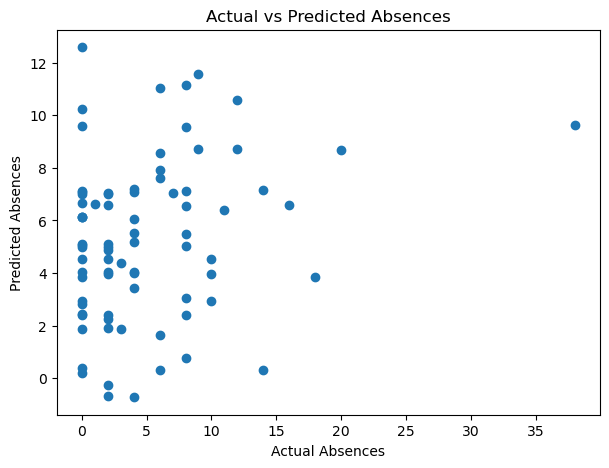

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Absences")
plt.ylabel("Predicted Absences")
plt.title("Actual vs Predicted Absences")

plt.show()

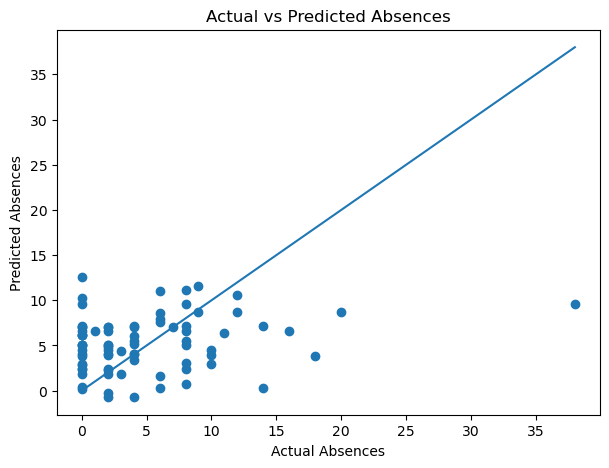

In [20]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Absences")
plt.ylabel("Predicted Absences")
plt.title("Actual vs Predicted Absences")

plt.show()

In [21]:
residuals = y_test - y_pred

print(residuals.head())

78    -5.031006
371   -1.390025
248    1.439202
55    -3.143148
390    4.590676
Name: absences, dtype: float64


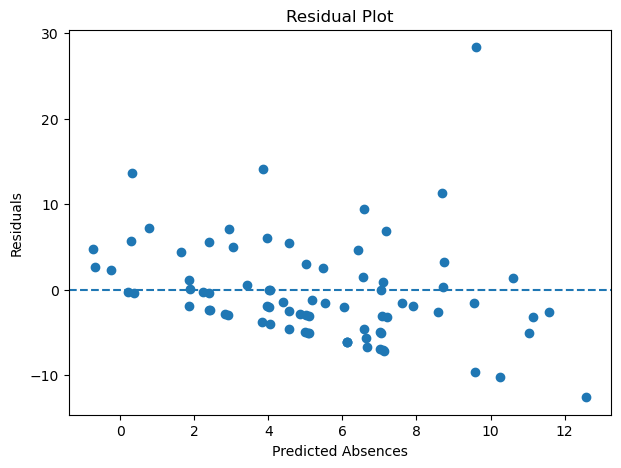

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Absences")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [23]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

          Feature  Coefficient
8    internet_yes     3.118277
0             age     1.566098
7  activities_yes     0.532550
1      traveltime     0.431133
3          health    -0.011230
2       studytime    -1.050163
5           sex_M    -2.686715
6       Pstatus_T    -4.461591
4       school_MS    -4.638213


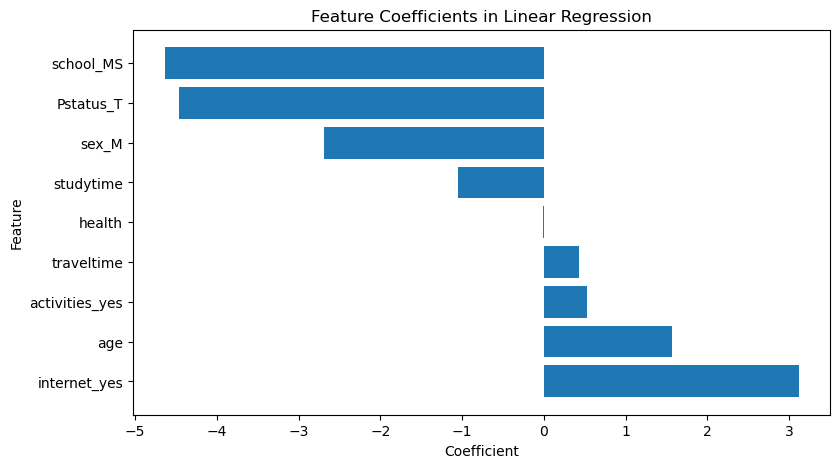

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients in Linear Regression")

plt.show()